## Active contour parameter search with Optuna

This notebook keeps the same **closed page contour** pipeline, but it adds **automatic parameter search**.

### Optimization idea
We do not have a true page mask here, so we use a **heuristic score**:

$$score = w_1 S_{edge} + w_2 S_{move} + w_3 S_{fill} - w_4 P_{border} - w_5 P_{area}$$

Here:
- $S_{edge}$: mean energy sampled on the contour
- $S_{move}$: how much the snake moved from the init contour
- $S_{fill}$: how well the detected page fills its own bounding box
- $P_{border}$: penalty when the contour stays too close to the image frame
- $P_{area}$: penalty when the page mask is too small or too large

So the search prefers a contour that moves, follows strong image structure, and still looks page-like.


## General parameters

These are the baseline values and the Optuna search settings.


In [4]:
# ---------------------------------
# Baseline configuration
# ---------------------------------

MAX_DIM = 1000
GAUSSIAN_SIGMA = 0.0
ENHANCEMENT_MODE = "none"
UNSHARP_RADIUS = 2.0
UNSHARP_AMOUNT = 1.5
ENERGY_MODE = "sobel"
SOBEL_BINARY_THRESHOLD = 0.16
CANNY_SIGMA = 2.0
CANNY_LOW_THRESHOLD = 0.10
CANNY_HIGH_THRESHOLD = 0.25
POST_ENERGY_BRIGHTEN_MODE = "gamma"
POST_ENERGY_GAMMA = 1.0
OUTER_BLACK_BORDER = 10
INIT_MARGIN_RATIO = 0.0
SNAKE_POINTS = 500
ALPHA = 5.0
BETA = 0.0
GAMMA = 0.01
W_LINE = 10.0
W_EDGE = 0.1
MAX_NUM_ITER = 10000
CONVERGENCE = 0.001

# ---------------------------------
# Search configuration
# ---------------------------------

OPTUNA_SEED = 7
N_TRIALS = 12
SEARCH_TIMEOUT_SECONDS = 300

# We keep these fixed during the search.
SEARCH_SNAKE_POINTS = SNAKE_POINTS
SEARCH_MAX_NUM_ITER = 3000
SEARCH_CONVERGENCE = CONVERGENCE

# Score weights.
WEIGHT_EDGE = 2.0
WEIGHT_MOVE = 0.8
WEIGHT_FILL = 0.7
WEIGHT_BORDER = 1.4
WEIGHT_AREA = 1.0

# Broad page-mask prior.
PAGE_AREA_LOW = 0.55
PAGE_AREA_HIGH = 0.92
BORDER_MARGIN = 12


## Sample parameters

These select the ECG image used in this notebook.


In [5]:
selected_ecg_id = "11842146"
selected_scan_type = "0005"


In [6]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    candidates = [current, current.parent, current.parent.parent]
    for candidate in candidates:
        if (candidate / "src").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not find the project root for src imports.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.core import PageScorePriors, PageScoreWeights
from src.io import find_sample_path, load_sample_rgb_image, rgb_to_gray_unit
from src.pipelines import (
    build_closed_page_detection_config,
    run_closed_page_detection,
    score_closed_page_detection,
)
from src.tuning import OptunaRunConfig, run_optuna_study, top_trials

optuna.logging.set_verbosity(optuna.logging.WARNING)


D:\Dev\ML\workspace\kaggle_challenges\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Reusable pipeline and tuning helpers

The page detector, the heuristic score, and the Optuna runner now come from `src`.
Only the search space itself stays local to this notebook.


In [7]:
sample_root = find_sample_path(PROJECT_ROOT)
rgb_img, image_path = load_sample_rgb_image(sample_root, selected_ecg_id, selected_scan_type)
gray_img = rgb_to_gray_unit(rgb_img)

score_weights = PageScoreWeights(
    edge=WEIGHT_EDGE,
    movement=WEIGHT_MOVE,
    fill=WEIGHT_FILL,
    border=WEIGHT_BORDER,
    area=WEIGHT_AREA,
)
score_priors = PageScorePriors(
    page_area_low=PAGE_AREA_LOW,
    page_area_high=PAGE_AREA_HIGH,
    border_margin=BORDER_MARGIN,
)
optuna_cfg = OptunaRunConfig(
    seed=OPTUNA_SEED,
    n_trials=N_TRIALS,
    timeout_seconds=SEARCH_TIMEOUT_SECONDS,
    direction="maximize",
)


## Step 1 - Baseline run

We first run the current manual configuration and score it with the heuristic objective.


Path: D:\Dev\ML\workspace\kaggle_challenges\Physionet_ECG_challenge\data\sample\11842146\11842146-0005.png
Baseline score: 1.098191
Baseline edge_support: 0.202528
Baseline movement: 0.060492
Baseline border_fraction: 0.000000
Baseline bbox_fill_ratio: 0.921058
Baseline page_area_ratio: 0.764069
Baseline area_penalty: 0.000000


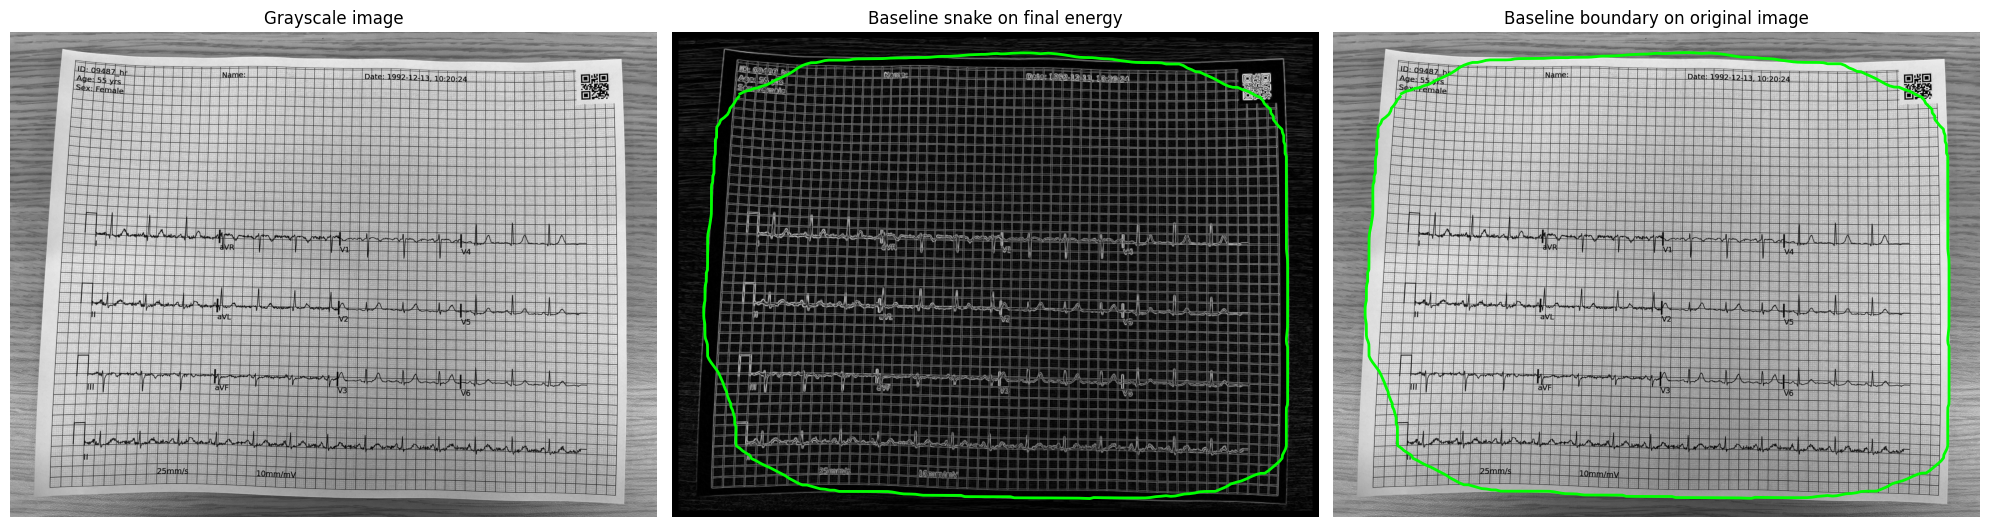

In [8]:
baseline_cfg = build_closed_page_detection_config(
    max_dim=MAX_DIM,
    enhancement_mode=ENHANCEMENT_MODE,
    unsharp_radius=UNSHARP_RADIUS,
    unsharp_amount=UNSHARP_AMOUNT,
    energy_mode=ENERGY_MODE,
    gaussian_sigma=GAUSSIAN_SIGMA,
    sobel_binary_threshold=SOBEL_BINARY_THRESHOLD,
    canny_sigma=CANNY_SIGMA,
    canny_low_threshold=CANNY_LOW_THRESHOLD,
    canny_high_threshold=CANNY_HIGH_THRESHOLD,
    post_brighten_mode=POST_ENERGY_BRIGHTEN_MODE,
    post_brighten_gamma=POST_ENERGY_GAMMA,
    outer_black_border=OUTER_BLACK_BORDER,
    init_margin_ratio=INIT_MARGIN_RATIO,
    snake_points=SNAKE_POINTS,
    alpha=ALPHA,
    beta=BETA,
    gamma=GAMMA,
    w_line=W_LINE,
    w_edge=W_EDGE,
    max_num_iter=MAX_NUM_ITER,
    convergence=CONVERGENCE,
)

baseline_result = run_closed_page_detection(gray_img, baseline_cfg)
baseline_metrics = score_closed_page_detection(baseline_result, score_weights, score_priors).as_dict()

print("Path:", image_path)
for key, value in baseline_metrics.items():
    print(f"Baseline {key}: {value:.6f}")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes[0].imshow(gray_img, cmap="gray")
axes[0].set_title("Grayscale image")
axes[0].axis("off")

axes[1].imshow(baseline_result.energy.final_energy, cmap="gray")
axes[1].plot(baseline_result.snake.final_snake[:, 1], baseline_result.snake.final_snake[:, 0], color="lime", linewidth=2)
axes[1].set_title("Baseline snake on final energy")
axes[1].axis("off")

axes[2].imshow(gray_img, cmap="gray")
axes[2].plot(baseline_result.mapping.mapped_snake[:, 1], baseline_result.mapping.mapped_snake[:, 0], color="lime", linewidth=2)
axes[2].set_title("Baseline boundary on original image")
axes[2].axis("off")

plt.tight_layout()
plt.show()


## Step 2 - Optuna objective

We keep the search space local to this notebook, but the reusable page-config builder, score function, and study runner now come from `src`.


In [9]:
def build_cfg_from_trial(trial: optuna.trial.Trial):
    enhancement_mode = trial.suggest_categorical("enhancement_mode", ["none", "unsharp"])
    energy_mode = trial.suggest_categorical("energy_mode", ["sobel", "laplace_abs", "laplace_abs_inv", "sobel_binary"])
    gaussian_sigma = trial.suggest_float("gaussian_sigma", 0.0, 2.0)
    sobel_binary_threshold = trial.suggest_float("sobel_binary_threshold", 0.08, 0.30)
    post_brighten_mode = trial.suggest_categorical("post_brighten_mode", ["none", "gamma"])
    if post_brighten_mode == "gamma":
        post_brighten_gamma = trial.suggest_float("post_brighten_gamma", 0.7, 1.4)
    else:
        post_brighten_gamma = 1.0

    return build_closed_page_detection_config(
        max_dim=MAX_DIM,
        enhancement_mode=enhancement_mode,
        unsharp_radius=UNSHARP_RADIUS,
        unsharp_amount=UNSHARP_AMOUNT,
        energy_mode=energy_mode,
        gaussian_sigma=gaussian_sigma,
        sobel_binary_threshold=sobel_binary_threshold,
        canny_sigma=CANNY_SIGMA,
        canny_low_threshold=CANNY_LOW_THRESHOLD,
        canny_high_threshold=CANNY_HIGH_THRESHOLD,
        post_brighten_mode=post_brighten_mode,
        post_brighten_gamma=post_brighten_gamma,
        outer_black_border=trial.suggest_int("outer_black_border", 0, 20),
        init_margin_ratio=trial.suggest_float("init_margin_ratio", 0.0, 0.08),
        snake_points=SEARCH_SNAKE_POINTS,
        alpha=trial.suggest_float("alpha", 0.2, 10.0, log=True),
        beta=trial.suggest_float("beta", 0.0, 1.0),
        gamma=trial.suggest_float("gamma", 0.001, 0.05, log=True),
        w_line=trial.suggest_float("w_line", 0.0, 15.0),
        w_edge=trial.suggest_float("w_edge", 0.0, 3.0),
        max_num_iter=SEARCH_MAX_NUM_ITER,
        convergence=SEARCH_CONVERGENCE,
    )


def objective(trial: optuna.trial.Trial) -> float:
    cfg = build_cfg_from_trial(trial)
    try:
        result = run_closed_page_detection(gray_img, cfg)
        metrics = score_closed_page_detection(result, score_weights, score_priors).as_dict()
    except Exception as exc:
        trial.set_user_attr("failed", str(exc))
        return -1e6

    for key, value in metrics.items():
        trial.set_user_attr(key, float(value))
    return metrics["score"]


## Step 3 - Run Optuna

We enqueue the baseline configuration first, then let Optuna search around it.


In [10]:
baseline_trial_params = {
    "enhancement_mode": ENHANCEMENT_MODE,
    "energy_mode": ENERGY_MODE,
    "gaussian_sigma": GAUSSIAN_SIGMA,
    "sobel_binary_threshold": SOBEL_BINARY_THRESHOLD,
    "post_brighten_mode": POST_ENERGY_BRIGHTEN_MODE,
    "post_brighten_gamma": POST_ENERGY_GAMMA,
    "outer_black_border": OUTER_BLACK_BORDER,
    "init_margin_ratio": INIT_MARGIN_RATIO,
    "alpha": ALPHA,
    "beta": BETA,
    "gamma": GAMMA,
    "w_line": W_LINE,
    "w_edge": W_EDGE,
}

study = run_optuna_study(
    objective,
    optuna_cfg,
    baseline_params=baseline_trial_params,
)

best_trial = study.best_trial
print(f"Best trial number: {best_trial.number}")
print(f"Best score: {best_trial.value:.6f}")
print("Best params:")
for key, value in best_trial.params.items():
    print(f"  {key}: {value}")

print("\nBest trial metrics:")
for key, value in best_trial.user_attrs.items():
    if isinstance(value, (int, float)):
        print(f"  {key}: {value:.6f}")
    else:
        print(f"  {key}: {value}")

print("\nTop 5 trials:")
for trial in top_trials(study, top_k=5):
    print(
        f"trial={trial.number:02d} "
        f"score={trial.value:.6f} "
        f"mode={trial.params.get('energy_mode')} "
        f"alpha={trial.params.get('alpha'):.4f} "
        f"w_line={trial.params.get('w_line'):.4f} "
        f"w_edge={trial.params.get('w_edge'):.4f}"
    )


Best trial number: 1
Best score: 2.615208
Best params:
  enhancement_mode: unsharp
  energy_mode: laplace_abs_inv
  gaussian_sigma: 1.0022409273198758
  sobel_binary_threshold: 0.09585124933914754
  post_brighten_mode: gamma
  post_brighten_gamma: 1.1754609972846581
  outer_black_border: 16
  init_margin_ratio: 0.03047529065188307
  alpha: 0.2588533985131201
  beta: 0.28814559930799355
  gamma: 0.03510525400519869
  w_line: 3.200780303698733
  w_edge: 1.3563718854530493

Best trial metrics:
  score: 2.615208
  edge_support: 0.968499
  movement: 0.015754
  border_fraction: 0.000000
  bbox_fill_ratio: 0.950867
  page_area_ratio: 0.844659
  area_penalty: 0.000000

Top 5 trials:
trial=01 score=2.615208 mode=laplace_abs_inv alpha=0.2589 w_line=3.2008 w_edge=1.3564
trial=10 score=2.521677 mode=laplace_abs_inv alpha=0.2020 w_line=0.1585 w_edge=1.1534
trial=11 score=2.488890 mode=laplace_abs_inv alpha=0.2482 w_line=0.0794 w_edge=1.1574
trial=07 score=1.792899 mode=sobel_binary alpha=1.8954 w_l

## Step 4 - Compare baseline and best trial

We rerun the best configuration and compare it with the manual baseline.


Baseline vs best:
score: baseline=1.098191 | best=2.615208
edge_support: baseline=0.202528 | best=0.968499
movement: baseline=0.060492 | best=0.015754
border_fraction: baseline=0.000000 | best=0.000000
bbox_fill_ratio: baseline=0.921058 | best=0.950867
page_area_ratio: baseline=0.764069 | best=0.844659
area_penalty: baseline=0.000000 | best=0.000000


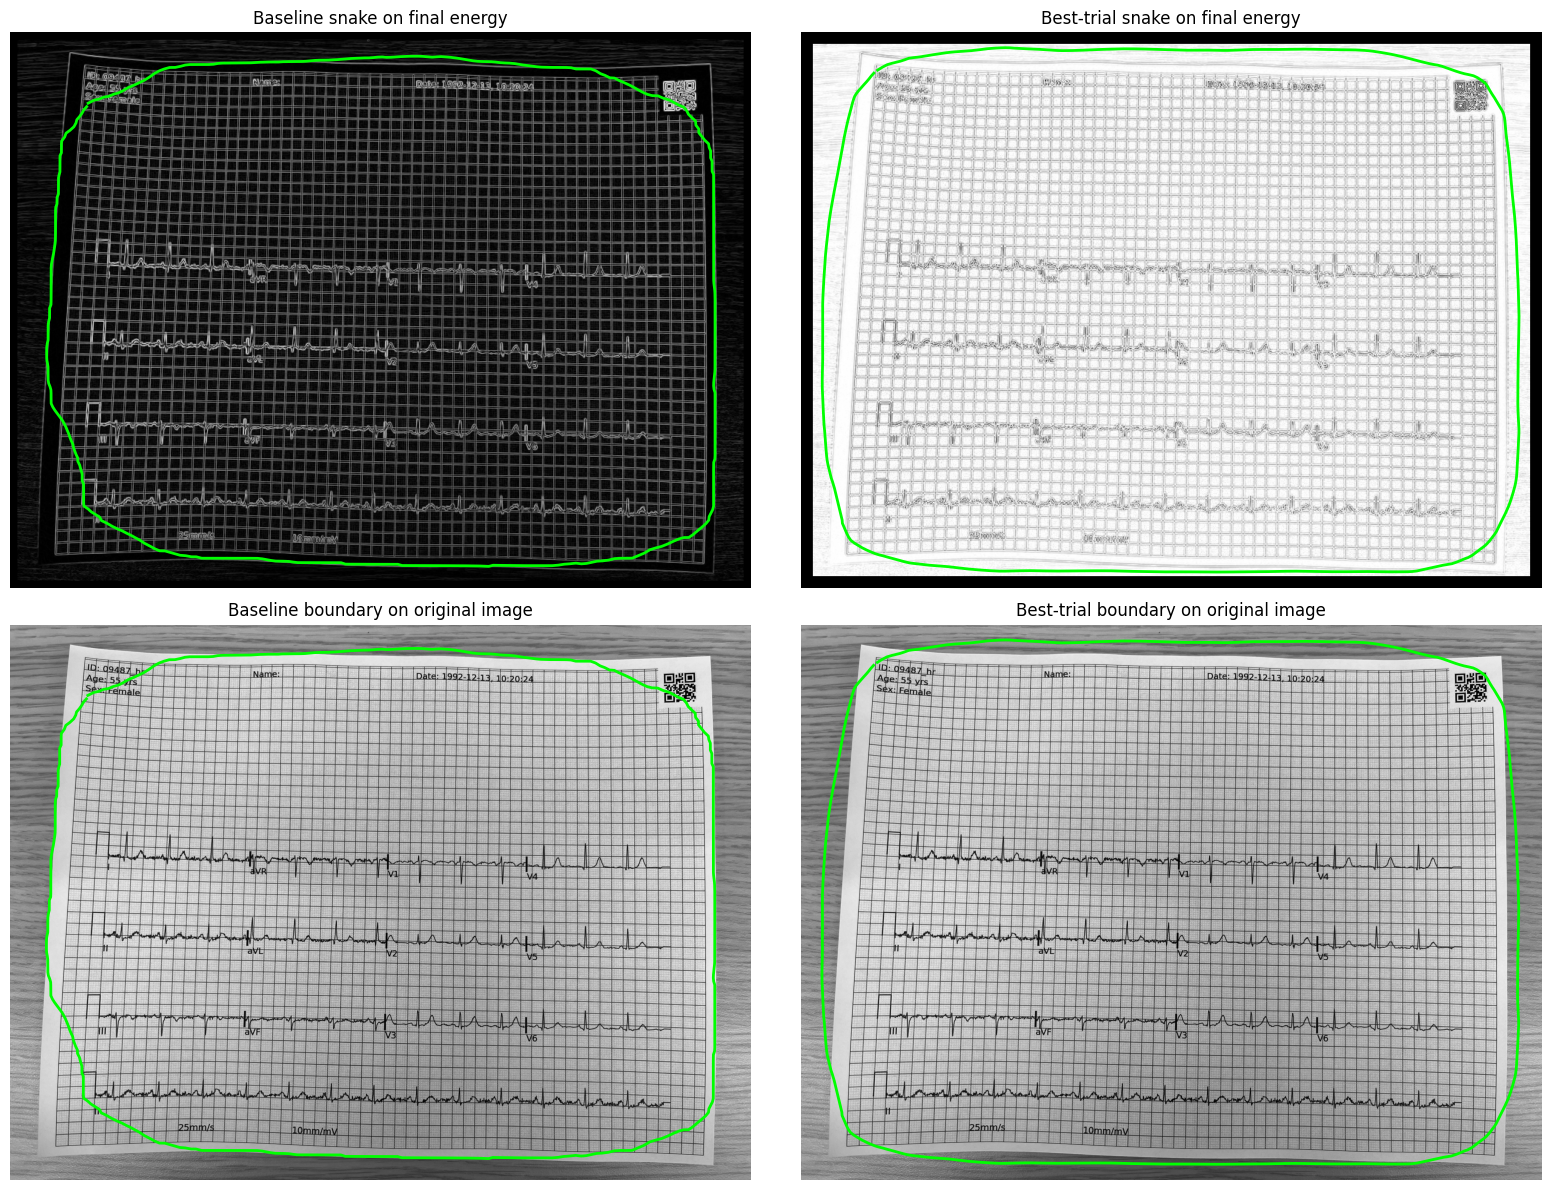

In [11]:
best_cfg = build_cfg_from_trial(optuna.trial.FixedTrial(best_trial.params))
best_result = run_closed_page_detection(gray_img, best_cfg)
best_metrics = score_closed_page_detection(best_result, score_weights, score_priors).as_dict()

print("Baseline vs best:")
for key in baseline_metrics.keys():
    print(f"{key}: baseline={baseline_metrics[key]:.6f} | best={best_metrics[key]:.6f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].imshow(baseline_result.energy.final_energy, cmap="gray")
axes[0, 0].plot(baseline_result.snake.final_snake[:, 1], baseline_result.snake.final_snake[:, 0], color="lime", linewidth=2)
axes[0, 0].set_title("Baseline snake on final energy")
axes[0, 0].axis("off")

axes[0, 1].imshow(best_result.energy.final_energy, cmap="gray")
axes[0, 1].plot(best_result.snake.final_snake[:, 1], best_result.snake.final_snake[:, 0], color="lime", linewidth=2)
axes[0, 1].set_title("Best-trial snake on final energy")
axes[0, 1].axis("off")

axes[1, 0].imshow(gray_img, cmap="gray")
axes[1, 0].plot(baseline_result.mapping.mapped_snake[:, 1], baseline_result.mapping.mapped_snake[:, 0], color="lime", linewidth=2)
axes[1, 0].set_title("Baseline boundary on original image")
axes[1, 0].axis("off")

axes[1, 1].imshow(gray_img, cmap="gray")
axes[1, 1].plot(best_result.mapping.mapped_snake[:, 1], best_result.mapping.mapped_snake[:, 0], color="lime", linewidth=2)
axes[1, 1].set_title("Best-trial boundary on original image")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()


## Conclusion

This notebook now reuses the shared page-detection pipeline, the shared heuristic score, and the shared Optuna runner from `src`.

The search does not use ground truth. It uses a geometric and image-based heuristic score.
So the best trial should be read as: **best according to this score on this image**, not as a universal best setting for all images.
